In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math
import seaborn as sns

names_bw=['time', 'bw', 'op1', 'size', 'op2' ]
names_latency=['time', 'latency', 'op2', 'write_size', 'op3']

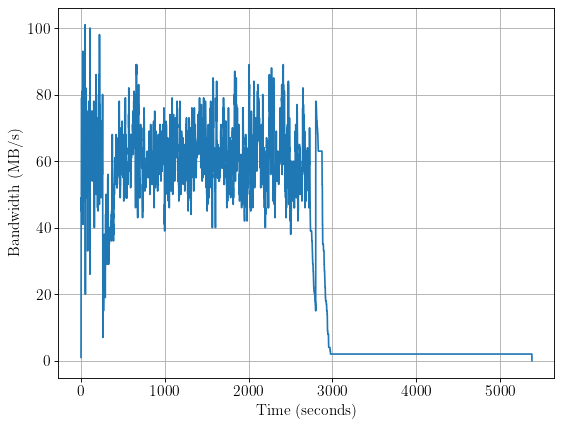

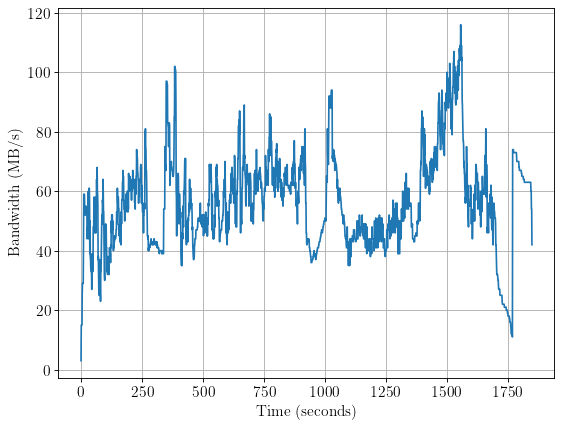

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the CSV file
names_latency=['submission_time', 'duration', 'op2', 'write_size', 'op3']
dirs = ["25Util", "50Util", "90Util"]
runs = ["run1", "run2"]
columns = ['submission_time', 'duration', 'write_size']
for run in runs:
  fname = f'/home/surbhi/measurements/worst_case/STL/1M/90-10-LBA/25Util/{run}/lat_log_avg_lat.1.log'
  df = pd.read_csv(fname, names=names_latency, usecols=columns)
  df['submission_time'] = df['submission_time'] - df.iloc[0].submission_time
  df['duration'] = df['duration']/(1e6) # convert nanoseconds to milliseconds
  df['completion_time'] = df['submission_time'] + df['duration']
  total_time = df.iloc[-1].completion_time
  
  bw_per_second = []
  time = []
  write_sz_per_sec = 0
  current_time = 0
  # total time % 1000 might not be zero.
  if (total_time % 1000):
      total_time = total_time + 1000
  while (current_time < total_time):
    write_sz_per_sec = df[(df['submission_time'] <= current_time) & (df['completion_time'] >= current_time)]['write_size'].sum()
    interval = (current_time - df[(df['submission_time'] <= current_time) & (df['completion_time'] >= current_time)]['submission_time']).mean()
    
    #write_sz_per_sec = 1 * (current_time - df['submission_time'])/df['duration']
    write_sz_per_sec =  df[(df['submission_time'] <= current_time) & (df['completion_time'] >= current_time)]['write_size'].sum()
    write_sz_per_sec = write_sz_per_sec/(1024 ** 2) # convert bytes to MB
    bw_per_second.append(write_sz_per_sec)
    time.append(current_time/1000)
    current_time += 1000 # we sum it up for 1000 milliseconds - ie 1 second

  plt.figure(figsize=(8, 6), dpi=80)
  plt.rc('text', usetex=True)
  plt.rc('font', family='serif')
  plt.rcParams['pdf.fonttype'] = 42
  plt.rcParams['ps.fonttype'] = 42

  
  plt.plot(time, bw_per_second)
  # xticks = np.arange(0, math.ceil(max(x)), 50)
  plt.xticks(fontsize=14)
  plt.yticks(fontsize=14)
  plt.xlabel('Time (seconds)', fontsize=14)
  plt.ylabel('Bandwidth (MB/s)', fontsize=14)

  plt.grid(True)  # Optionally, add grid lines
  #name=dir.split("Util")
  #plt.title(f"45 GB writes with DM-Hybrid. Zone is {name[0]} \% full")
  #plt.savefig(f'/home/surbhi/github/surbhi-plots/new/STL/{dir}_{run}.png', bbox_inches='tight')
  plt.show()


  
  


  
  
  


  
  
